In [2]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse import csc_matrix, eye, hstack, vstack, kron
import pymatching
import matplotlib.pyplot as plt
import json
import os
import time

sqrt_pi = np.sqrt(np.pi) # to write less later on
sqrt_2 = np.sqrt(2)

n_trials = 5000

The Toric code is the 2D surface code

https://pymatching.readthedocs.io/en/latest/toric-code-example.html

Need to make new repettition code and stabilisers to get them in the correct matrix shape for time dimension added, also need to accound for peroidic boundary conditions(?)

The tutorial uses X stabs and Z errors i tink so i will do it this way round first

The toric code is fully symetric to the periodic boundary conditions and lattic dimensions so just producing and decoding for one of the Z or X type errors is sufficient to mimic all errors.

In [3]:
def toric_rep_code(n):
    row = np.repeat(np.arange(n), 2)
    col = np.zeros(2 * n, dtype=int)
    for i in range(n):
        col[2 * i] = i
        col[2 * i + 1] = (i + 1) % n
    data = np.ones(2 * n, dtype=np.uint8)
    return csc_matrix((data, (row, col)), shape=(n, n))

def toric_x_stab(d):
    Hr = toric_rep_code(d)
    I = eye(d, dtype=np.uint8)
    H = hstack([kron(Hr, I), kron(I, Hr)])
    H.data = H.data % 2
    H.eliminate_zeros()
    return csc_matrix(H)

def toric_logical_x(d):
    num_qubits = 2 * (d ** 2)
    log1 = np.zeros(num_qubits, dtype=np.uint8)
    log2 = np.zeros(num_qubits, dtype=np.uint8)
    
    for i in range(d):
        log1[i] = 1
        log2[d**2 + i*d] = 1 
        
    logicals = np.vstack([log1, log2])
    return csc_matrix(logicals)

For noise simulation in the 3d toric code, the tutorial uses a random noise and here the gaussian needs to be used

The gaussian and self correction is done for each rep - which is each surface code over time

this is then used to get the cumulative noise as is done in the tutorial

Start with ideal gkp errors- the measurement is assumed to be correct - this is to test the toric code functions built actually work so far. 

Phenomological noise model

Weights in pymatching relate to measurment probability in the aper this uses $\gamma$

$$\gamma_{synd} = log[(\frac{1-q}{q})]$$

$$\gamma_i = log[\frac{Pr(\tilde{s_i}|s_1=+1)}{Pr(\tilde{s_i}|s_1=-1)}]$$

am pretty sure im doing hard syndrome decoding of H dot e 

do i have to add the gammas into the for loop above?

but is this the big noise error i just want gaussian noise error error 

$$\gamma \approx log(\frac{P_{even}}{P_{odd}})$$

$$weights (\gamma) = \frac{(\sqrt{\pi}-|s|)^2 - s^2}{2 \sigma^2}$$

This is for the gaussian noise eorr - in ideal case, will need to use similar or ideally the same weights when adding measurement error.

In [4]:
def gkp_toric_qubit_only(d, sigma_vals, n_trials=1000):
    Hx = toric_x_stab(d)
    logical_x = toric_logical_x(d)
    num_qubits = Hx.shape[1]

    matching = pymatching.Matching.from_check_matrix(Hx)
    
    logical_rates = []

    for sigma in sigma_vals:
        logical_errors = 0

        for _ in range(n_trials):
            # generate gkp and error
            dp = np.random.normal(0, sigma, num_qubits)
            sp_vals = ((dp + sqrt_pi / 2) % sqrt_pi) - sqrt_pi / 2
            kp = np.round((dp - sp_vals) / sqrt_pi).astype(int)
            ep = kp % 2  

            weights_p = ((sqrt_pi - np.abs(sp_vals)) ** 2 - sp_vals ** 2) / (2 * sigma ** 2)
    
            syndrome = (Hx @ ep) % 2
            correction = matching.decode(syndrome, weights=weights_p, as_weights=True)
            residual_error = (ep + correction) % 2
            if np.any((logical_x @ residual_error) % 2):
                logical_errors += 1

        rate = logical_errors / n_trials
        logical_rates.append(rate)
        #print(f"d={d}, Sigma={sigma:.3f} -> Logical Rate: {rate:.4f}")
        
    return logical_rates

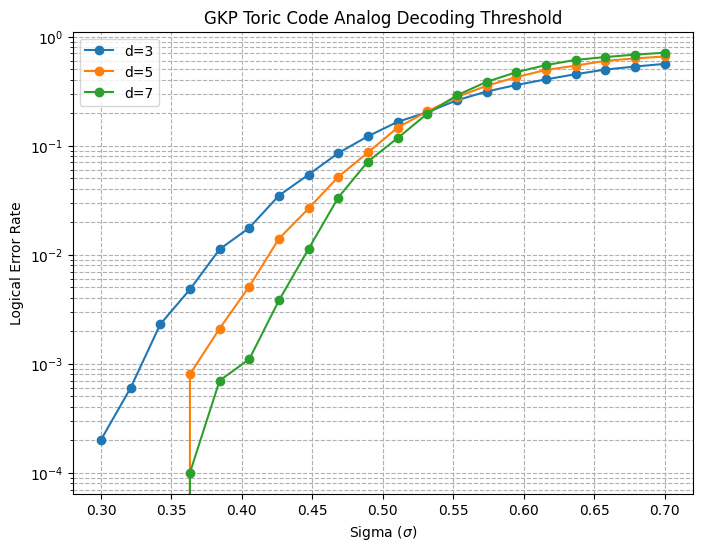

In [5]:
sigma_vals = np.linspace(0.3, 0.7, 20)
distances = [3, 5, 7]

plt.figure(figsize=(8, 6))

for d in distances:
    rates = gkp_toric_qubit_only(d, sigma_vals, n_trials=10000)
    plt.plot(sigma_vals, rates, marker='o', label=f'd={d}')

plt.yscale('log')
plt.xlabel(r"Sigma ($\sigma$)")
plt.ylabel("Logical Error Rate")
plt.title("GKP Toric Code Analog Decoding Threshold")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Now looking at these but over time, so repettitions of the surface code are done 

For this the measurment also has error and this error value decides if another set of checks is none after the first one

Trying to use the tutorial and reps like this doesnt seem to work well with the gkp displacement error so it can also be donw manually

## Error bars on th system

binomial thing

https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval

$sd = \sqrt{\frac{p(1-p)}{N}} $

for lower error rates can also use wilson or cooper pearson confidence intervals 

sigma_vals = np.linspace(0.2, 0.7 , 20)
distances = [3, 5, 7]
shots_by_d = {3: 20000, 5: 20000, 7: 10000}

plt.figure(figsize=(8, 6))

for d in distances:
    rates, errs = run_gkp_toric_spacetime_simulation(d, sigma_vals, shots_by_d[d])
    plt.errorbar(sigma_vals, rates, yerr = errs, capsize=3, label=f'd={d}, T={d}')

plt.xlabel(r"Sigma ($\sigma$)")
plt.ylabel("Logical Error Rate")
plt.title("GKP toric over time not logged")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def run_gkp_toric_spacetime_simulation(d, sigma_vals, max_trials=50000, min_errors=100, min_trials=1000, save_filename="simulation_checkpoint.json"):
    Hx = toric_x_stab(d)
    logical_x = toric_logical_x(d)
    num_qubits = Hx.shape[1]
    num_stabilisers = Hx.shape[0]
    T = d 
    
    H_space = kron(eye(T + 1, dtype=np.uint8), Hx)
    I_stab = eye(num_stabilisers, dtype=np.uint8)
    
    Row_time = []
    for i in range(T + 1):
        row_blocks = []
        for j in range(T):
            if i == j or i == j + 1:
                row_blocks.append(I_stab)
            else:
                row_blocks.append(csc_matrix((num_stabilisers, num_stabilisers), dtype=np.uint8))
        Row_time.append(hstack(row_blocks))
    H_time = vstack(Row_time)
    
    H_3D = hstack([H_space, H_time])
    H_3D.data = H_3D.data % 2
    H_3D.eliminate_zeros()

    matching = pymatching.Matching.from_check_matrix(H_3D)

    #data
    if os.path.exists(save_filename):
        with open(save_filename, 'r') as f:
            saved_data = json.load(f)
        print(f"Loaded existing checkpoint data from {save_filename}")
    else:
        saved_data = {}

    str_d = str(d)
    if str_d not in saved_data:
        saved_data[str_d] = {"sigma": [], "rate": [], "error_bar": [], "total_trials": [], "total_errors": []}

    last_save_time = time.time()

    for sigma in sigma_vals:
        sigma_rounded = round(float(sigma), 5)
        
        #get data from file for quicker plots
        if sigma_rounded in saved_data[str_d]["sigma"]:
            idx = saved_data[str_d]["sigma"].index(sigma_rounded)
            existing_trials = saved_data[str_d]["total_trials"][idx]
            existing_errors = saved_data[str_d]["total_errors"][idx]
            
            if existing_trials >= max_trials or (existing_errors >= min_errors and existing_trials >= min_trials):
                print(f"Existing data for d={d}, sigma={sigma_rounded} (has {existing_trials} trials)")
                continue
            else:
                # if interupted bc laptop died a few times 
                print(f"Resuming d={d}, sigma={sigma_rounded} from {existing_trials} to max {max_trials} trials...")
                logical_errors = existing_errors
                trials_run = existing_trials
        else:
            # new data if none saved
            print(f"Simulating new data: d={d}, sigma={sigma_rounded}...")
            logical_errors = 0
            trials_run = 0

        while trials_run < max_trials:
            batch_size = min(500, max_trials - trials_run)  #batch for daster processing still takes a while tho
            
            for _ in range(batch_size):
                qubit_errors_per_step = []
                qubit_weights_per_step = []
                cumulative_ep = np.zeros(num_qubits, dtype=np.uint8)
                
                for t in range(T):
                    dp = np.random.normal(0, sigma, num_qubits)
                    sp_vals = ((dp + sqrt_pi / 2) % sqrt_pi) - sqrt_pi / 2
                    ep_slice = (np.round((dp - sp_vals) / sqrt_pi).astype(int)) % 2
                    cumulative_ep = (cumulative_ep + ep_slice) % 2
                    qubit_errors_per_step.append(ep_slice)
                    space_w = ((sqrt_pi - np.abs(sp_vals)) ** 2 - sp_vals ** 2) / (2 * sigma ** 2)
                    qubit_weights_per_step.append(space_w)
                
                ideal_syndromes = []
                current_qubit_state = np.zeros(num_qubits, dtype=np.uint8)
                for t in range(T):
                    current_qubit_state = (current_qubit_state + qubit_errors_per_step[t]) % 2
                    ideal_syndromes.append((Hx @ current_qubit_state) % 2)
                    
                meas_weights_per_step = []
                meas_errors_per_step = []
                noisy_syndromes = []
                for t in range(T):
                    meas_dp = np.random.normal(0, sigma, num_stabilisers)
                    meas_sp = ((meas_dp + sqrt_pi / 2) % sqrt_pi) - sqrt_pi / 2
                    meas_ep = (np.round((meas_dp - meas_sp) / sqrt_pi).astype(int)) % 2
                    noisy_slice = (ideal_syndromes[t] + meas_ep) % 2
                    noisy_syndromes.append(noisy_slice)
                    meas_errors_per_step.append(meas_ep)
                    time_w = ((sqrt_pi - np.abs(meas_sp)) ** 2 - meas_sp ** 2) / (2 * sigma ** 2)
                    meas_weights_per_step.append(time_w)
                    
                detectors = []
                prev_syndrome = np.zeros(num_stabilisers, dtype=np.uint8) 
                for t in range(T + 1):
                    current_syn = noisy_syndromes[t] if t < T else (Hx @ cumulative_ep) % 2
                    dt = (current_syn + prev_syndrome) % 2
                    detectors.append(dt)
                    prev_syndrome = current_syn
                    
                full_detector_syndrome = np.concatenate(detectors)
                full_weights_vector = np.concatenate(qubit_weights_per_step + meas_weights_per_step)

                correction = matching.decode(full_detector_syndrome, weights=full_weights_vector, as_weights=True)
                cumulative_correction = np.zeros(num_qubits, dtype=np.uint8)
                for t in range(T):
                    layer_start = t * num_qubits
                    cumulative_correction = (cumulative_correction + correction[layer_start:layer_start + num_qubits]) % 2
                    
                residual_error = (cumulative_ep + cumulative_correction) % 2
                if np.any((logical_x @ residual_error) % 2):
                    logical_errors += 1

            trials_run += batch_size
            
            # stop if enough errors 
            if logical_errors >= min_errors and trials_run >= min_trials:
                break

        # rates
        rate = logical_errors / trials_run
        err = np.sqrt(rate * (1 - rate) / trials_run) if trials_run > 0 else 0

        # update data in correct columns 
        if sigma_rounded in saved_data[str_d]["sigma"]:
            idx = saved_data[str_d]["sigma"].index(sigma_rounded)
            saved_data[str_d]["rate"][idx] = float(rate)
            saved_data[str_d]["error_bar"][idx] = float(err)
            saved_data[str_d]["total_trials"][idx] = int(trials_run)
            saved_data[str_d]["total_errors"][idx] = int(logical_errors)
        else:
            saved_data[str_d]["sigma"].append(sigma_rounded)
            saved_data[str_d]["rate"].append(float(rate))
            saved_data[str_d]["error_bar"].append(float(err))
            saved_data[str_d]["total_trials"].append(int(trials_run))
            saved_data[str_d]["total_errors"].append(int(logical_errors))

        #5 mins = save data
        current_time = time.time()
        if (current_time - last_save_time) > 300 or sigma == sigma_vals[-1]:
            with open(save_filename, 'w') as f:
                json.dump(saved_data, f, indent=4)
            print(f"--> Saved progress checkpoint to {save_filename} (Total Trials: {trials_run}, Total Errors: {logical_errors})")
            last_save_time = current_time

    # sort data
    sorted_indices = np.argsort(saved_data[str_d]["sigma"])
    out_sigmas = [saved_data[str_d]["sigma"][i] for i in sorted_indices]
    out_rates = [saved_data[str_d]["rate"][i] for i in sorted_indices]
    out_errs = [saved_data[str_d]["error_bar"][i] for i in sorted_indices]

    return out_sigmas, out_rates, out_errs

In [4]:
# --- NEW CELL FOR ADDING EXTRA DATA POINTS ---

# 1. Choose the distance you want to increase precision for
target_d = 20

# 2. Generate finely-spaced sigma values around your suspected threshold
# Example: 15 points focused tightly between 0.31 and 0.36
precise_sigmas = np.linspace(0.39, 0.42, 15) 

checkpoint_file = "gkp_toric_spacetime_results.json"
max_allowed_shots = 1000000 

print(f"Running targeted high-resolution points for d={target_d}...")

# This will ONLY simulate the new sigma values you provided
run_gkp_toric_spacetime_simulation(
    d=target_d, 
    sigma_vals=precise_sigmas, 
    max_trials=max_allowed_shots, 
    min_errors=200, 
    min_trials=5000,
    save_filename=checkpoint_file
)

print("Targeted simulation complete! The points are now saved in your JSON file.")

Running targeted high-resolution points for d=20...
Loaded existing checkpoint data from gkp_toric_spacetime_results.json
Simulating new data: d=20, sigma=0.39...
Simulating new data: d=20, sigma=0.39214...
Simulating new data: d=20, sigma=0.39429...
Simulating new data: d=20, sigma=0.39643...
Simulating new data: d=20, sigma=0.39857...
Simulating new data: d=20, sigma=0.40071...
Simulating new data: d=20, sigma=0.40286...
Simulating new data: d=20, sigma=0.405...
Simulating new data: d=20, sigma=0.40714...
Simulating new data: d=20, sigma=0.40929...
--> Saved progress checkpoint to gkp_toric_spacetime_results.json (Total Trials: 5000, Total Errors: 934)
Simulating new data: d=20, sigma=0.41143...
Simulating new data: d=20, sigma=0.41357...
Simulating new data: d=20, sigma=0.41571...
Simulating new data: d=20, sigma=0.41786...
Simulating new data: d=20, sigma=0.42...
--> Saved progress checkpoint to gkp_toric_spacetime_results.json (Total Trials: 5000, Total Errors: 2513)
Targeted simu

Loaded existing checkpoint data from gkp_toric_spacetime_results.json
Simulating new data: d=3, sigma=0.1...
Simulating new data: d=3, sigma=0.11724...
--> Saved progress checkpoint to gkp_toric_spacetime_results.json (Total Trials: 1000000, Total Errors: 0)
Simulating new data: d=3, sigma=0.13448...
Simulating new data: d=3, sigma=0.15172...
--> Saved progress checkpoint to gkp_toric_spacetime_results.json (Total Trials: 1000000, Total Errors: 0)
Simulating new data: d=3, sigma=0.16897...
Simulating new data: d=3, sigma=0.18621...
--> Saved progress checkpoint to gkp_toric_spacetime_results.json (Total Trials: 1000000, Total Errors: 0)
Simulating new data: d=3, sigma=0.20345...
Simulating new data: d=3, sigma=0.22069...
--> Saved progress checkpoint to gkp_toric_spacetime_results.json (Total Trials: 1000000, Total Errors: 0)
Simulating new data: d=3, sigma=0.23793...
Simulating new data: d=3, sigma=0.25517...
--> Saved progress checkpoint to gkp_toric_spacetime_results.json (Total Tri

KeyboardInterrupt: 

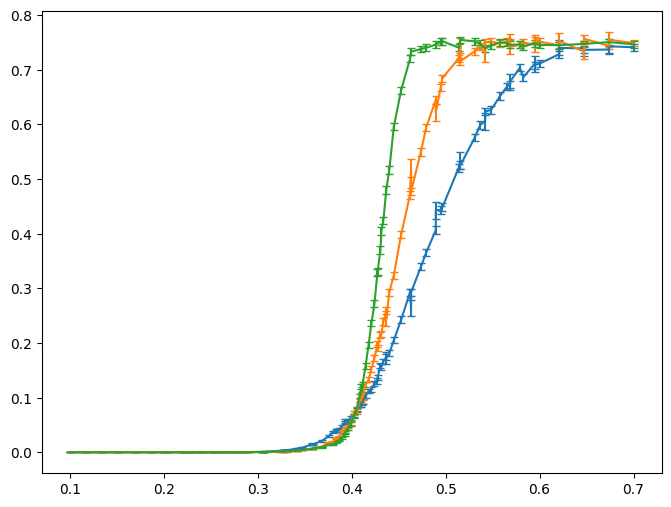

In [4]:
sigma_vals = np.linspace(0.1, 0.6, 30)
distances = [3, 5, 9, 11, 15, 20]
checkpoint_file = "gkp_toric_spacetime_results.json"

plt.figure(figsize=(8, 6))

for d in distances:
    max_allowed_shots = 1000000 
    
    # Skips points already saved in JSON
    rates_sigma, rates, errs = run_gkp_toric_spacetime_simulation(
        d=d, 
        sigma_vals=sigma_vals, 
        max_trials=max_allowed_shots, 
        min_errors=200, 
        min_trials=5000,
        save_filename=checkpoint_file
    )
    
    # DYNAMICALLY LOAD AND SORT ALL DATA FROM THE FILE
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, 'r') as f:
            all_data = json.load(f)
        
        d_str = str(d)
        if d_str in all_data:
            valid_sigmas = []
            valid_rates = []
            valid_errs = []
            
            # Loop through all keys and safely ignore anything that isn't a number
            for s in all_data[d_str].keys():
                try:
                    # Try to convert the key to a float (e.g. "0.32" -> 0.32)
                    sigma_num = float(s) 
                    
                    # If conversion succeeds, grab its data
                    valid_sigmas.append(sigma_num)
                    valid_rates.append(all_data[d_str][s]['rate'])
                    valid_errs.append(all_data[d_str][s]['error'])
                except ValueError:
                    # If it's 'sigma', 'rate', or any other text metadata, silently skip it
                    continue
            
            # Convert lists to numpy arrays
            saved_sigmas = np.array(valid_sigmas)
            saved_rates = np.array(valid_rates)
            saved_errs = np.array(valid_errs)
            
            # Only sort and plot if we actually found numeric data for this distance
            if len(saved_sigmas) > 0:
                sort_idx = np.argsort(saved_sigmas)
                rates_sigma = saved_sigmas[sort_idx]
                rates = saved_rates[sort_idx]
                errs = saved_errs[sort_idx]
    
    # Plot the beautifully combined, sorted high-resolution curve
    plt.errorbar(rates_sigma, rates, yerr=errs, capsize=3, label=f'd={d}, T={d}')

plt.yscale('log')
plt.xlabel(r"Sigma ($\sigma$)")
plt.ylabel("Logical Error Rate")
plt.ylim(1e-4, 1)
plt.xlim(0.3, 0.6)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Loaded existing checkpoint data from gkp_toric_spacetime_results.json
Existing data for d=3, sigma=0.38 (has 5500 trials)
Existing data for d=3, sigma=0.38316 (has 5000 trials)
Existing data for d=3, sigma=0.38632 (has 5000 trials)
Existing data for d=3, sigma=0.38947 (has 5000 trials)
Existing data for d=3, sigma=0.39263 (has 5000 trials)
Existing data for d=3, sigma=0.39579 (has 5000 trials)
Existing data for d=3, sigma=0.39895 (has 5000 trials)
Existing data for d=3, sigma=0.40211 (has 5000 trials)
Existing data for d=3, sigma=0.40526 (has 5000 trials)
Existing data for d=3, sigma=0.40842 (has 5000 trials)
Existing data for d=3, sigma=0.41158 (has 5000 trials)
Existing data for d=3, sigma=0.41474 (has 5000 trials)
Existing data for d=3, sigma=0.41789 (has 5000 trials)
Existing data for d=3, sigma=0.42105 (has 5000 trials)
Existing data for d=3, sigma=0.42421 (has 5000 trials)
Existing data for d=3, sigma=0.42737 (has 5000 trials)
Existing data for d=3, sigma=0.43053 (has 5000 trials

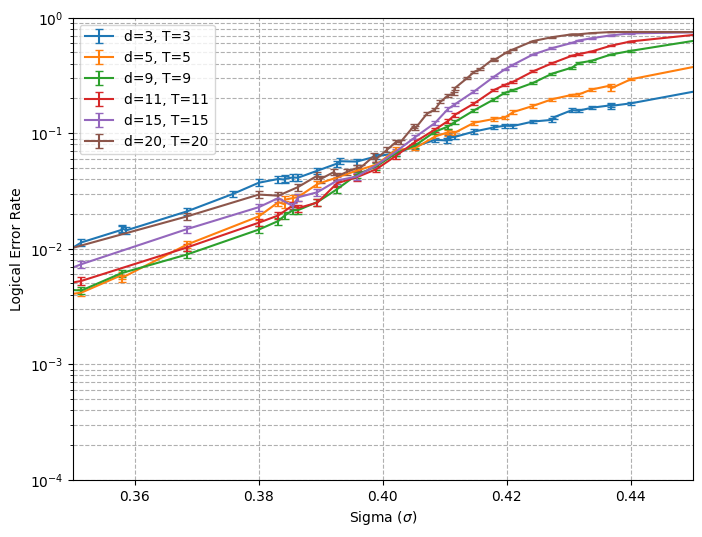

In [10]:
sigma_vals = np.linspace(0.38, 0.44, 20)
distances = [3, 5, 9, 11, 15, 20]
checkpoint_file = "gkp_toric_spacetime_results.json"

plt.figure(figsize=(8, 6))

for d in distances:
    max_allowed_shots = 1000000 #might need to increase even tho high bc low sigma still has rly high error
    
    rates_sigma, rates, errs = run_gkp_toric_spacetime_simulation(
        d=d, 
        sigma_vals=sigma_vals, 
        max_trials=max_allowed_shots, 
        min_errors=200, 
        min_trials=5000,
        save_filename=checkpoint_file
    )
    plt.errorbar(rates_sigma, rates, yerr=errs, capsize=3, label=f'd={d}, T={d}')

plt.yscale('log')
plt.xlabel(r"Sigma ($\sigma$)")
plt.ylabel("Logical Error Rate")
plt.ylim(1e-4, 1.0)
plt.xlim(0.35, 0.45)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

In [ ]:
#phys cluster to get more data for better supression - ask Lucca and if not holly = DONE
#soft vs discrete information - do not feed into middle qubits - soft should be better which is why gkp qubits are good
#qldpc codes w hypergraph product 
#use examples - eventualy make own

In [6]:
with open("gkp_toric_spacetime_results.json", "r") as f:
    sample_data = json.load(f)

# Print keys to check how the dictionary is nested
print("Top-level keys:", list(sample_data.keys()))
# Take a peek inside the first key's contents
first_key = list(sample_data.keys())[0]
print(f"\nSample data under key '{first_key}':")
print(str(sample_data[first_key])[:400], "...")

Top-level keys: ['3', '5', '7', '9', '15', '20', '11']

Sample data under key '3':
{'sigma': [0.2, 0.22631578947368422, 0.25263157894736843, 0.2789473684210526, 0.30526315789473685, 0.3315789473684211, 0.35789473684210527, 0.38421052631578945, 0.4105263157894737, 0.4368421052631579, 0.4631578947368421, 0.48947368421052634, 0.5157894736842106, 0.5421052631578946, 0.5684210526315789, 0.5947368421052632, 0.6210526315789473, 0.6473684210526316, 0.6736842105263158, 0.7, 0.22632, 0.25 ...


In [8]:
with open("gkp_toric_spacetime_results.json", "r") as f:
    data = json.load(f)

# Look at all the keys inside the distance '3' dictionary
print(data['3'].keys())

dict_keys(['sigma', 'rate', 'error_bar', 'total_trials', 'total_errors'])


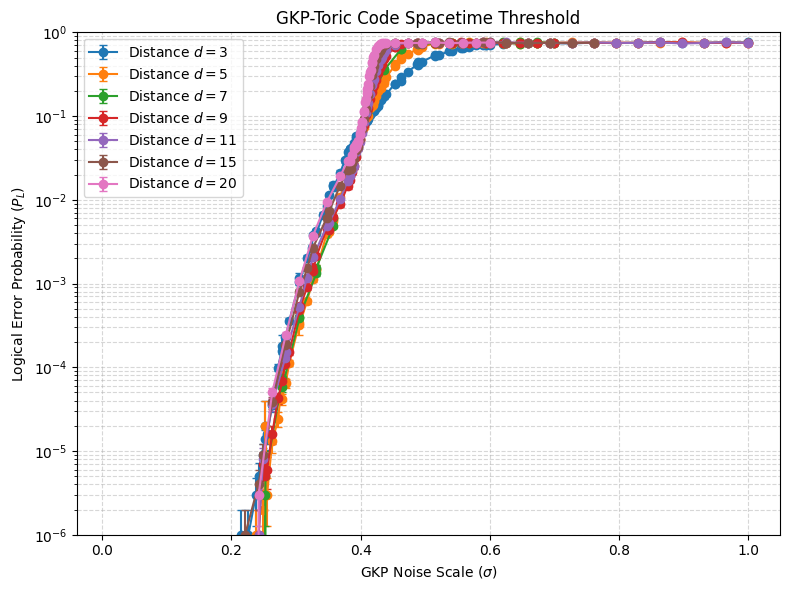

In [12]:
import json
import matplotlib.pyplot as plt

# 1. Load the cluster data
file_path = "gkp_toric_spacetime_results.json"
with open(file_path, "r") as f:
    data = json.load(f)

plt.figure(figsize=(8, 6))

# 2. Parse and plot data per distance
# Top-level keys are your distances: '3', '5', '7', etc.
for distance in sorted(data.keys(), key=int):
    sim_lists = data[distance]
    
    sigmas = sim_lists['sigma']
    logical_rates = sim_lists['rate']
    error_bars = sim_lists['error_bar']
    
    # Sort everything together by sigma to keep the lines smooth
    sorted_data = sorted(zip(sigmas, logical_rates, error_bars), key=lambda x: x[0])
    sorted_sigmas, sorted_rates, sorted_errors = zip(*sorted_data)
    
    # Plot using error bars for scientific accuracy
    plt.errorbar(
        sorted_sigmas, 
        sorted_rates, 
        yerr=sorted_errors, 
        fmt='-o', 
        capsize=3, 
        label=f"Distance $d={distance}$"
    )

# 3. Format the GKP-Toric QEC threshold plot
plt.xlabel(r"GKP Noise Scale ($\sigma$)")
plt.ylabel(r"Logical Error Probability ($P_L$)")
plt.title("GKP-Toric Code Spacetime Threshold")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.yscale("log") 
plt.ylim(10e-7, 1)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import json
import matplotlib.pyplot as plt

with open(checkpoint_file) as f:
    data = json.load(f)

plt.figure(figsize=(8, 6))

for sigma in sigma_vals:
    rates = []
    valid_distances = []

    for d in distances:
        values = data[str(d)]
        sigma_rounded = round(float(sigma), 5)

        if sigma_rounded in values["sigma"]:
            i = values["sigma"].index(sigma_rounded)
            rate = values["rate"][i]

            if rate > 0:
                valid_distances.append(d)
                rates.append(rate)

    plt.plot(valid_distances, rates, "o-", label=f"$\\sigma={sigma:.2f}$")

plt.yscale("log")
plt.xlabel("Code distance $d$")
plt.ylabel("Logical error probability $P_L$")
plt.grid(True, which="both", linestyle="--")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig("exponential_suppression.png", dpi=300)